In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [35]:
train = pd.read_csv("Linear Regression Train.csv")
test = pd.read_csv("Linear Regression Test.csv")

print(train.head())
print(test.head())
X = train.drop(columns=['target']).values
y = train['target'].values
X_test=test



   feat_1   feat_2  feat_3  feat_4  feat_5  feat_6  feat_7   feat_8    feat_9  \
0 -0.8589  32.0681  0.8988 -0.9199  3.2330  0.8989 -0.6383  16910.0  187.9845   
1 -0.3604  16.1950  1.4917 -1.0816 -0.5577  1.4918  0.7571   8370.0  155.7592   
2  0.3321  11.0785  0.5486 -0.3012 -0.5602  0.5487 -0.6599  17204.0  189.5140   
3 -0.9664 -18.9944 -0.9897 -1.2719  0.1397 -0.9896 -2.0511  16016.0  182.5419   
4 -0.5001  46.4172  0.9271  0.7189 -0.6647  0.9272 -0.7340  19998.0  203.7299   

   feat_10  feat_11  feat_12  feat_13  feat_14  feat_15  target  
0    522.0  -0.4012  -0.0372   0.0682   0.1680  98.5600    25.0  
1   1164.0   0.2620   0.0356   0.1224   0.7190  59.7760    67.0  
2   1440.0   0.1922   0.4314   0.1546   0.8879  33.4151    86.0  
3    166.0   0.4422   1.7373   0.0238   1.2060  56.5375     5.0  
4   2450.0   0.3864   2.0814   0.2525  -0.1641  14.0241   122.0  
   feat_1   feat_2  feat_3  feat_4  feat_5  feat_6  feat_7   feat_8    feat_9  \
0  0.6915  25.5722 -0.9571 -0.8410 -

In [36]:
np.random.seed(42)

n = X.shape[0]
indices = np.random.permutation(n)

split = int(0.8 * n)
train_idx = indices[:split]
val_idx   = indices[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]


In [37]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train=(X_train-mean)/std
X_val=(X_val-mean)/std
X_test=(X_test-mean)/std

In [38]:
def compute_cost(X, y, w, b):
    m = X_train.shape[0]
    f_wb = X_train @ w + b
    cost = (1 / (2 * m)) * np.sum((f_wb - y_train) ** 2)
    return cost

In [39]:
def compute_gradient(X, y, w, b):
    m = X_train.shape[0]
    f_wb = X_train @ w + b       # shape (m,)
    err = f_wb - y_train         # shape (m,)
    dj_dw = (1 / m) * (X_train.T @ err)
    dj_db = (1 / m) * np.sum(err)
    return dj_dw, dj_db


In [40]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []
    grad_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X_train, y_train, w, b)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Store history
        cost = compute_cost(X_train, y_train, w, b)
        cost_history.append(cost)
        grad_history.append(np.linalg.norm(dj_dw))  # gradient magnitude

    return w, b, cost_history, grad_history


In [41]:
n = X_train.shape[1]
w = np.zeros(n)
b = 0
alpha = 0.1
iterations = 2000

w, b, cost_history,grad_history = gradient_descent(X_train, y_train, w, b, alpha, iterations)
print("Final weights of w",w)
print("Final weights of b",b)
print("Final cost",cost_history[-1])


Final weights of w [ 4.94206177e-03 -1.45739710e-03 -7.14933343e-03  1.01845572e-02
  8.47083145e-03 -7.14933343e-03 -4.64932130e-03  8.71845641e+00
 -7.30378033e+00  8.73469894e+01  1.12954895e-02 -2.38297829e-05
 -2.77291352e+01 -2.82966275e-03 -7.46949831e-01]
Final weights of b 88.317591666668
Final cost 61.20719299765947


In [42]:
y_train_pred = X_train @ w + b
y_val_pred   = X_val   @ w + b
y_test_pred  = X_test  @ w+ b



In [43]:

y_train_pred = (X_train @ w).reshape(-1) + b
y_train_pred=y_train_pred.reshape(-1,1)

print("y_train_pred:", y_train_pred.shape)

y_train_pred: (480000, 1)


In [44]:
def r2_score(y, y_pred):
    y = y.reshape(-1)
    y_pred = y_pred.reshape(-1)
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res / ss_tot)



In [45]:
print("Val   R2:", r2_score(y_val, y_val_pred))


















Val   R2: 0.9683631756031161


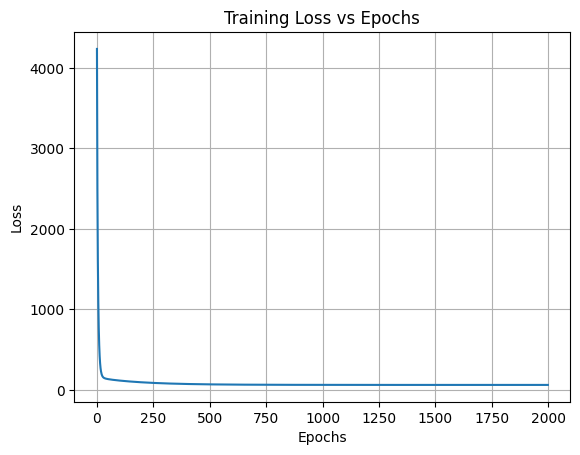

In [46]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()


In [53]:
def plot_data_points( X, y, y_pred=None, Title="Predictions vs Actual"):
        plt.figure()
        plt.scatter(X, y, label="Actual")
        if y_pred is not None:
            plt.scatter(X, y_pred, label="Predicted")
        plt.legend()
        plt.title(Title)
        plt.show()


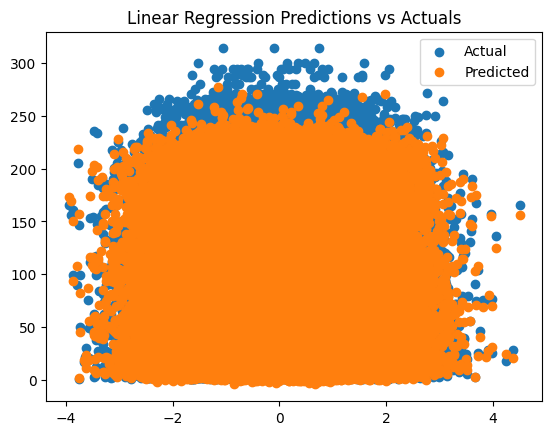

In [57]:

plot_data_points(X=X_val[:,0],y= y_val,y_pred=y_val_pred,Title='Linear Regression Predictions vs Actuals')


In [60]:
linear = pd.DataFrame({
    "target": y_test_pred
})

linear.to_csv("linear.csv", index=False)
print("linear.csv created!")


linear.csv created!
